In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm
import matplotlib.cm as cm
import duckdb
from pathlib import Path
import mpl_scatter_density

In [2]:
# angmomdir = Path("/Volumes/newpassport/tables/spheres")
# made_spheres = [f.stem for f in angmomdir.glob("*.parquet")]
clu_params = pd.read_csv("../data/clu_params.csv")

In [3]:
name = "ASCC_19"
dvtlim = 2

clu_params = clu_params.loc[clu_params.name == name]
r_clu = clu_params[["x", "y", "z"]].to_numpy().flatten()

df = duckdb.query(f"""
    SELECT * FROM '/Volumes/newpassport/spheres/{name}.parquet'
    WHERE parallax_over_error > 10
""").df()

print("N: ", len(df))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

N:  925706


In [29]:
bar = df.sample(n=20000).copy()

In [30]:
plx = bar["parallax"]
e_plx = bar["parallax_error"]

factor = np.cos(np.deg2rad(bar.l)) * np.cos(np.deg2rad(bar.b))

bar["sigma_x"] = np.abs(1000 * e_plx * factor / plx**2)

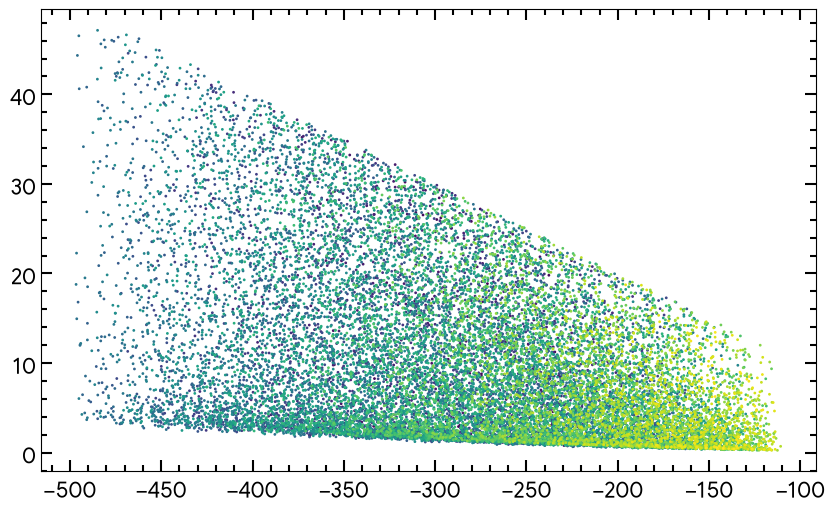

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

ix = np.argsort(bar.l)
bar = bar.iloc[ix].reset_index(drop=True)

ax.scatter(bar.X, bar.sigma_x, c=bar.l, cmap="viridis", s=1)

plt.show()

In [63]:
halfedge = 195 / np.sqrt(3)

cube_cond = (
    df.X.between(r_clu[0] - halfedge, r_clu[0] + halfedge)
    & df.Y.between(r_clu[1] - halfedge, r_clu[1] + halfedge)
    & df.Z.between(r_clu[2] - halfedge, r_clu[2] + halfedge)
)

foo = df.loc[cube_cond]

In [59]:
foo = foo.sample(n=50000)

/Users/sharifi/Documents/escapees/.venv/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/Users/sharifi/Documents/escapees/.venv/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill

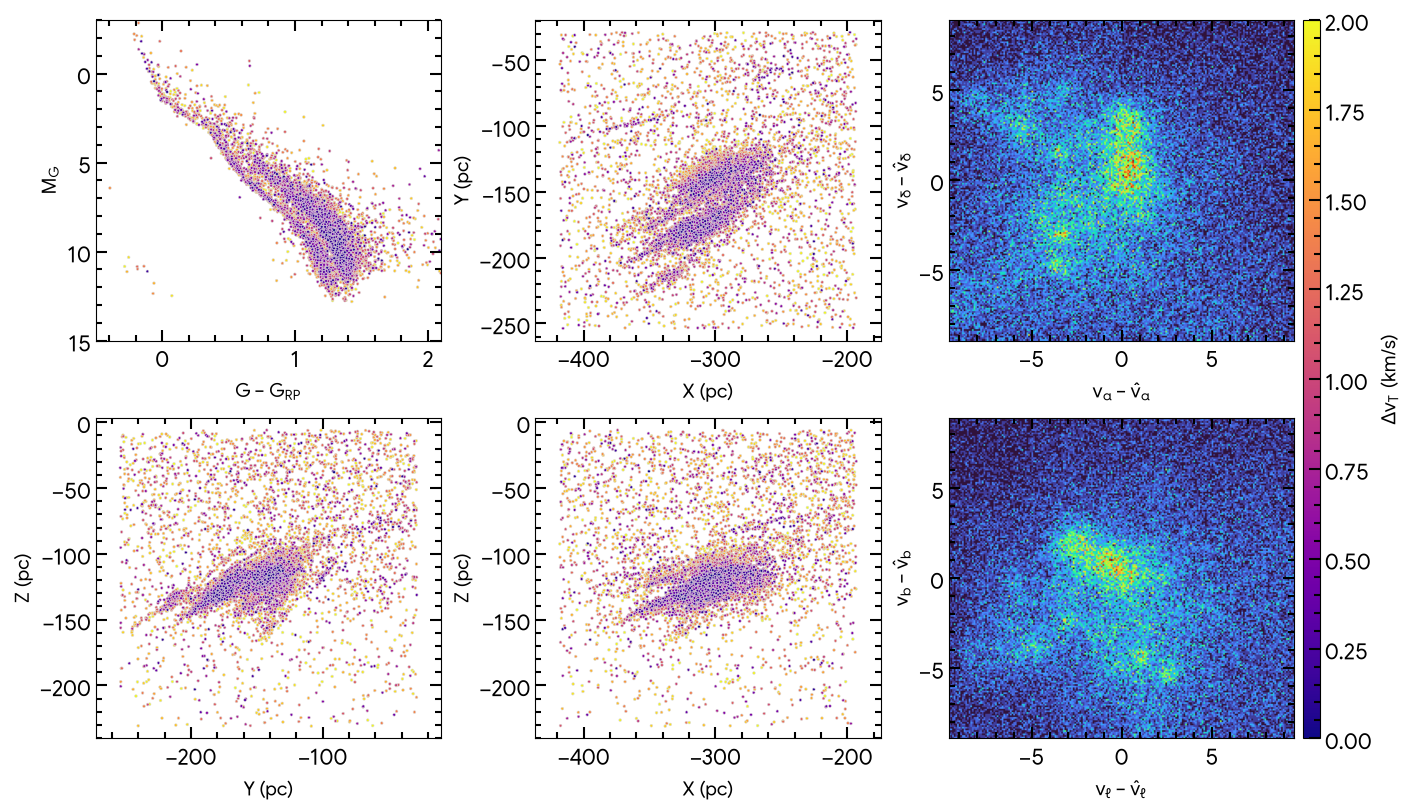

In [ ]:
fig = plt.figure(
    figsize=(14, 8),
    constrained_layout=True,
)
gs = fig.add_gridspec(2, 4, width_ratios=[1] * 3 + [0.05])  # last column for colorbar
axes = np.empty((2, 3), dtype=object)
for i in range(2):
    for j in range(3):
        axes[i, j] = fig.add_subplot(gs[i, j], projection="scatter_density")

cmap_dvt = cm.plasma
cax = fig.add_subplot(gs[:, -1])
norm_dvt = Normalize(0, dvtlim)
mappable = cm.ScalarMappable(norm=norm_dvt, cmap=cmap_dvt)
cbar = fig.colorbar(mappable, cax=cax)
cbar.set_label(r"$\Delta v_T\ (km/s)$", fontsize=14)

ix = np.flip(np.argsort(foo.delta_vT))
foo = foo.iloc[ix]

xys = (
    (
        foo.g_rp.loc[foo.delta_vT < dvtlim],
        foo.phot_g_mean_mag.loc[foo.delta_vT < dvtlim]
        + 5 * np.log10(foo.parallax.loc[foo.delta_vT < dvtlim] / 100),
    ),
    (foo.X.loc[foo.delta_vT < dvtlim], foo.Y.loc[foo.delta_vT < dvtlim]),
    (foo.delta_vra, foo.delta_vdec),
    (foo.Y.loc[foo.delta_vT < dvtlim], foo.Z.loc[foo.delta_vT < dvtlim]),
    (foo.X.loc[foo.delta_vT < dvtlim], foo.Z.loc[foo.delta_vT < dvtlim]),
    (foo.delta_vl, foo.delta_vb),
)
labels = (
    (r"$G-G_{RP}$", r"$M_G$"),
    ("X (pc)", "Y (pc)"),
    (r"$v_\alpha-\hat{v}_\alpha$", r"$v_\delta-\hat{v}_\delta$"),
    ("Y (pc)", "Z (pc)"),
    ("X (pc)", "Z (pc)"),
    (r"$v_\ell - \hat{v}_\ell$", r"$v_b - \hat{v}_b$"),
)


for i, (xy, label) in enumerate(zip(xys, labels)):
    ax = axes[i // 3, i % 3]
    ax.set_xlabel(label[0], fontsize=14)
    ax.set_ylabel(label[1], fontsize=14)

    if i % 3 != 2:
        ax.scatter(
            xy[0],
            xy[1],
            c=foo.delta_vT.loc[foo.delta_vT < dvtlim],
            cmap=cmap_dvt,
            norm=norm_dvt,
            s=4,
            edgecolors="gainsboro",
            linewidth=0.4,
        )

    if i == 0:
        ax.set_xlim(-0.5, 2.1)
        ax.set_ylim(-3, 15)
        ax.invert_yaxis()

    if i % 3 == 2:
        ax.scatter_density(xy[0], xy[1], cmap="turbo", dpi=60)
        # ax.hexbin(
        #     xy[0],
        #     xy[1],
        #     gridsize=200,
        #     cmap="Grays",
        #     # bins="log",
        #     mincnt=1,
        #     extent=[-10, 10] + list(np.sort([-10, 10])),
        # )
        ax.set_xlim(-10, 10)
        ax.set_ylim(-10, 10)

    if i != 0:
        ax.set_aspect("equal", adjustable="datalim")


plt.savefig(
    f"/Volumes/newpassport/plots/{name}.png",
    dpi=400,
    bbox_inches="tight",
)

plt.show()

In [70]:
ax.scatter_density?

Signature:
ax.scatter_density(
    x,
    y,
    dpi=72,
    downres_factor=4,
    color=None,
    cmap=None,
    alpha=1.0,
    norm=None,
    **kwargs,
)
Docstring:
Make a density plot of the (x, y) scatter data.

Parameters
----------
x, y : iterable
    The data to plot
dpi : int or `None`
    The number of dots per inch to include in the density map. To use
    the native resolution of the drawing device, set this to None.
downres_factor : int
    For interactive devices, when panning, the density map will
    automatically be made at a lower resolution and including only a
    subset of the points. The new dpi of the figure when panning will
    then be dpi / downres_factor, and the number of elements in the
    arrays will be reduced by downres_factor**2.
cmap : `matplotlib.colors.Colormap`
    The colormap to use for the density map.
color : str or tuple
    The color to use for the density map. This can be any valid
    Matplotlib color. If specified, this takes precedence ove

In [88]:
hclu = pd.read_csv("/Volumes/newpassport/litclusterdatabases/HR24/HR24_clusters.csv")
clu_params = pd.read_csv("../data/clu_params.csv")

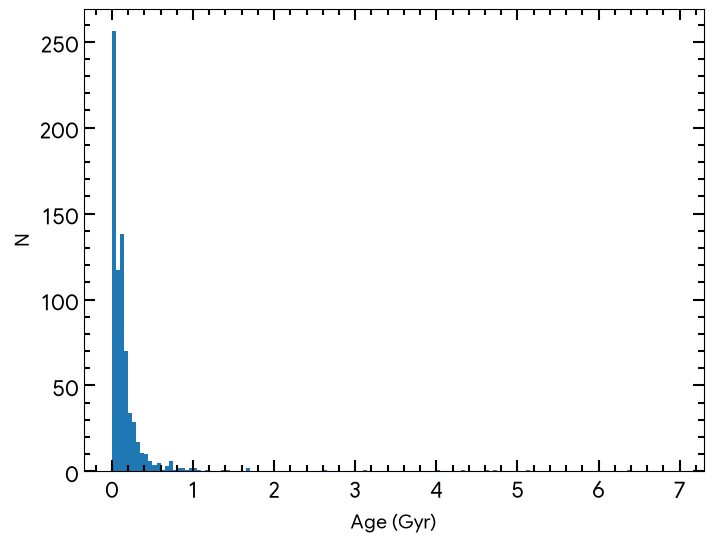

In [104]:
fig, ax = plt.subplots(figsize=(8, 6))

foo = hclu.loc[(hclu.Type == "o") & (hclu.dist50 < 1000)]
# hclu.Name.isin(clu_params.name) &
ax.hist((10**foo.logAge50) / 1e9, bins=np.arange(0, 7, 0.05))

ax.set_xlabel("Age (Gyr)", fontsize=14)
ax.set_ylabel("N", fontsize=14)
# ax.semilogy()
plt.show()